In [21]:
import tensorflow as tf
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# Load the SavedModel
model = tf.saved_model.load("models/yolo11n_tf")
infer = model.signatures["serving_default"]



In [22]:
def preprocess_image(path, size=(640, 640)):
    image = Image.open(path).convert("RGB").resize(size)
    img_np = np.array(image, dtype=np.float32) / 255.0
    img_np = img_np.transpose(2, 0, 1)  # HWC → CHW
    img_tensor = tf.convert_to_tensor(img_np[np.newaxis, ...])  # Add batch
    return img_tensor, image

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def draw_detections(image, boxes, scores, classes, label="person"):
    draw = ImageDraw.Draw(image)
    for box, score in zip(boxes, scores):
        x1, y1, x2, y2 = map(int, box)
        label_text = f"{label}: {score:.2f}"
        draw.rectangle([x1, y1, x2, y2], outline="lime", width=2)
        draw.text((x1, y1 - 10), label_text, fill="white")
    return image

In [44]:
def postprocess(preds, image_size=(640, 640), conf_thresh=0.28, iou_thresh=0.45):
    preds = preds[0].numpy()  # shape: (84, 8400)
    preds = preds.transpose(1, 0)  # (8400, 84)

    boxes = preds[:, :4]                         # (cx, cy, w, h)
    objectness = sigmoid(preds[:, 4])
    person_scores = sigmoid(preds[:, 5])         # Only class 0 ("person")

    conf = objectness * person_scores
    mask = conf > conf_thresh
    boxes, conf = boxes[mask], conf[mask]

    if len(boxes) == 0:
        return np.empty((0, 4)), np.empty((0,)), np.empty((0,), dtype=int)

    # Convert boxes: cx, cy, w, h → x1, y1, x2, y2
    cx, cy, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    x1 = cx - w / 2
    y1 = cy - h / 2
    x2 = cx + w / 2
    y2 = cy + h / 2
    boxes_xyxy = np.stack([x1, y1, x2, y2], axis=1)

    # NMS
    selected = tf.image.non_max_suppression(
        boxes=boxes_xyxy,
        scores=conf,
        max_output_size=50,
        iou_threshold=iou_thresh,
        score_threshold=conf_thresh
    )

    selected_boxes = boxes_xyxy[selected]
    selected_scores = conf[selected]
    selected_classes = np.zeros_like(selected_scores, dtype=int)  # class 0 for person

    return selected_boxes, selected_scores, selected_classes


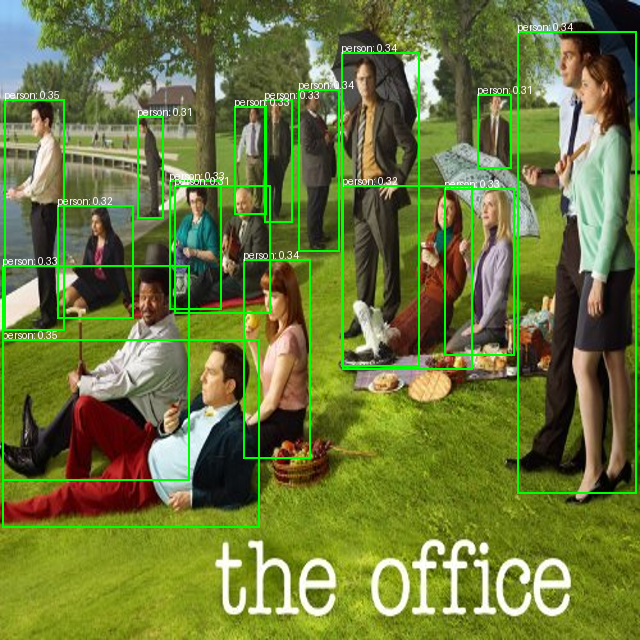

In [53]:
image_path = "group_test/office5.jpg"
input_tensor, pil_image = preprocess_image(image_path)
output = infer(images=input_tensor)["output0"]
boxes, scores, classes = postprocess(output)
draw_detections(pil_image, boxes, scores, classes)